# 第065讲 对偶与核技巧

逐步检查解析对偶、偏置区间、精确特征映射与原始/对偶数值证据。

In [1]:
from pathlib import Path
import numpy as np, json
from IPython.display import display, Image
from dual import solve_dual, polynomial_features, gram, validate_gram
from experiment import run
from plots import build
from common import write_json
print('第065讲；个人结果保存到 outputs/notebook')

第065讲；个人结果保存到 outputs/notebook


## 两点解析解和无内部支持向量的情形

In [2]:
X=np.array([[-1.],[1.]])
y=np.array([-1.,1.])
for C in (1.,.1):
    d=solve_dual(X@X.T,y,C)
    print(C,'alpha',d['alpha'],'bias',d['bias_recovery'],'audit',d['audit'])

1.0 alpha [0.5, 0.5] bias {'method': 'free_support_vectors', 'free_count': 2, 'spread': 0.0} audit {'primal_value': 0.5, 'dual_value': 0.5, 'gap': 0.0, 'equality_residual': 0.0, 'box_violation': 0.0, 'margin_complementarity': 0.0, 'slack_complementarity': 0.0}
0.1 alpha [0.0999999999999998, 0.0999999999999998] bias {'method': 'bound_interval', 'free_count': 0, 'lower': -0.8000000000000004, 'upper': 0.8000000000000004} audit {'primal_value': 0.18, 'dual_value': 0.17999999999999966, 'gap': 3.3306690738754696e-16, 'equality_residual': 0.0, 'box_violation': 0.0, 'margin_complementarity': 0.0, 'slack_complementarity': 1.6653345369377356e-16}


## 显式映射与PSD反例

In [3]:
X=np.array([[1.,2.],[3.,4.]])
Phi=polynomial_features(X)
print('kernel',gram(X))
print('explicit',Phi@Phi.T)
try:
    validate_gram([[1,2],[2,1]])
except ValueError as exc:
    print('正确拒绝非法相似度:',exc)

kernel [[ 25. 121.]
 [121. 625.]]
explicit [[ 25. 121.]
 [121. 625.]]
正确拒绝非法相似度: Gram must be PSD within tolerance


## 从头执行多路线核验

In [4]:
result=run()
write_json('outputs/notebook/result.json',result)
print('KKT audit',result['dual']['audit'])
print('independent primal difference',result['primal_dual_objective_difference'])
print('test score equivalence',result['test']['max_explicit_kernel_difference'])
print('test accuracy',result['test']['accuracy'])

KKT audit {'primal_value': 1.0616022116888597, 'dual_value': 1.0616022116888464, 'gap': 1.3322676295501878e-14, 'equality_residual': 1.1102230246251565e-15, 'box_violation': 0.0, 'margin_complementarity': 4.950183917321801e-15, 'slack_complementarity': 0.0}
independent primal difference 4.163114297739412e-12
test score equivalence 1.7763568394002505e-15
test accuracy 1.0


In [5]:
print('free-support-vector bias', result['dual']['bias_recovery'])
print('feature-space w',result['dual_reconstructed_w'])
print('smallest Gram eigenvalue',min(result['gram_eigenvalues']))

free-support-vector bias {'method': 'free_support_vectors', 'free_count': 2, 'spread': 9.325873406851315e-15}
feature-space w [0.19066389766052824, -1.4087056919707177, 0.31999996080611764]
smallest Gram eigenvalue -4.832247880311795e-15


## 六幅图由当前运行结果重建并嵌入

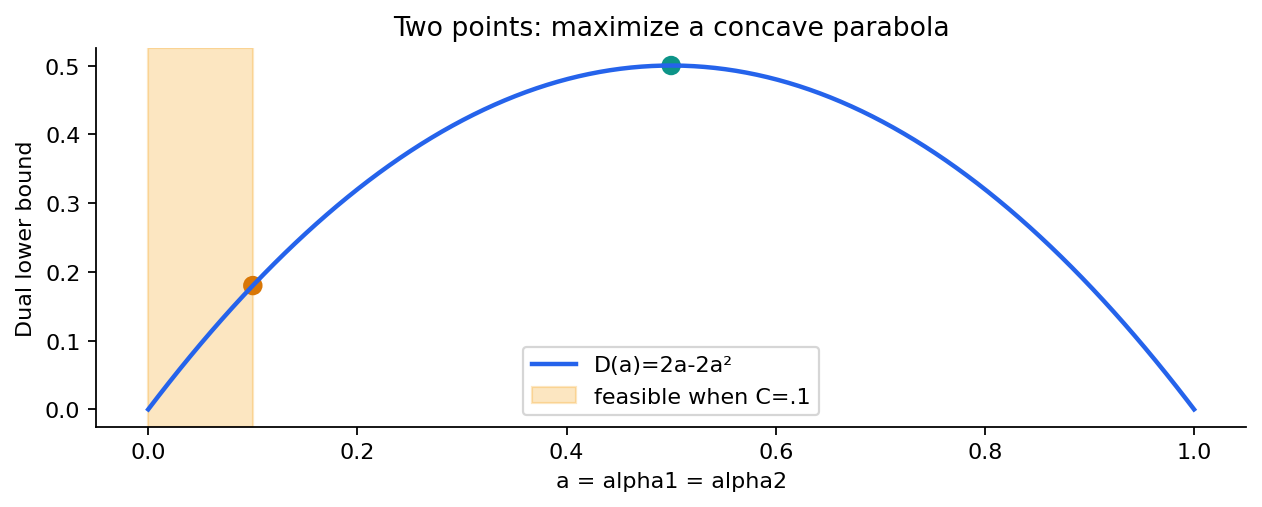

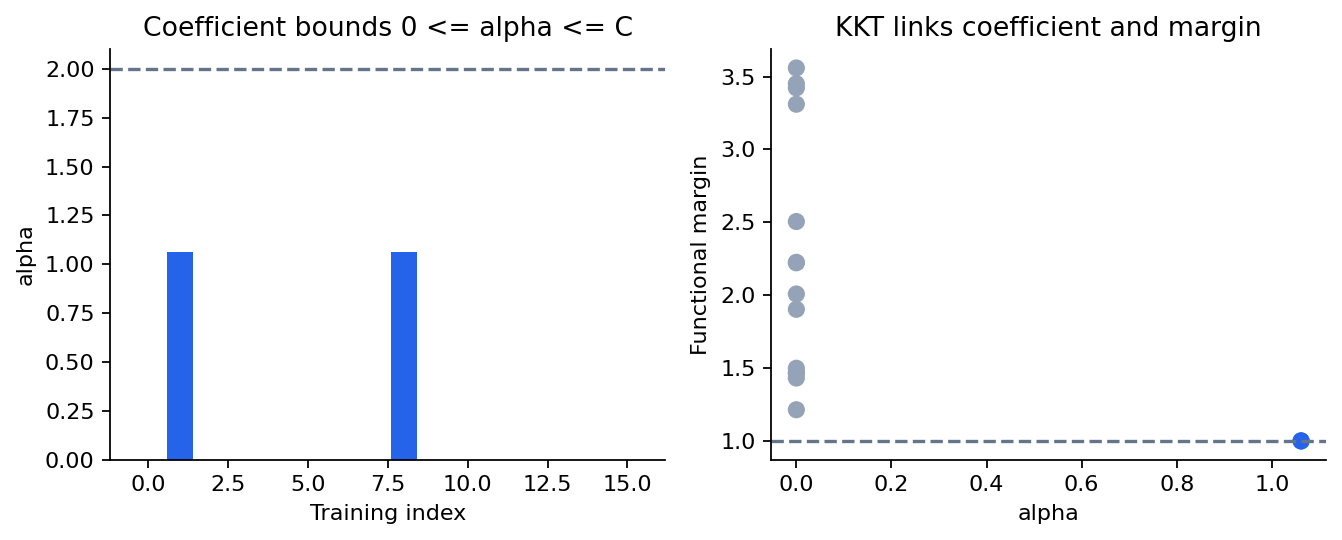

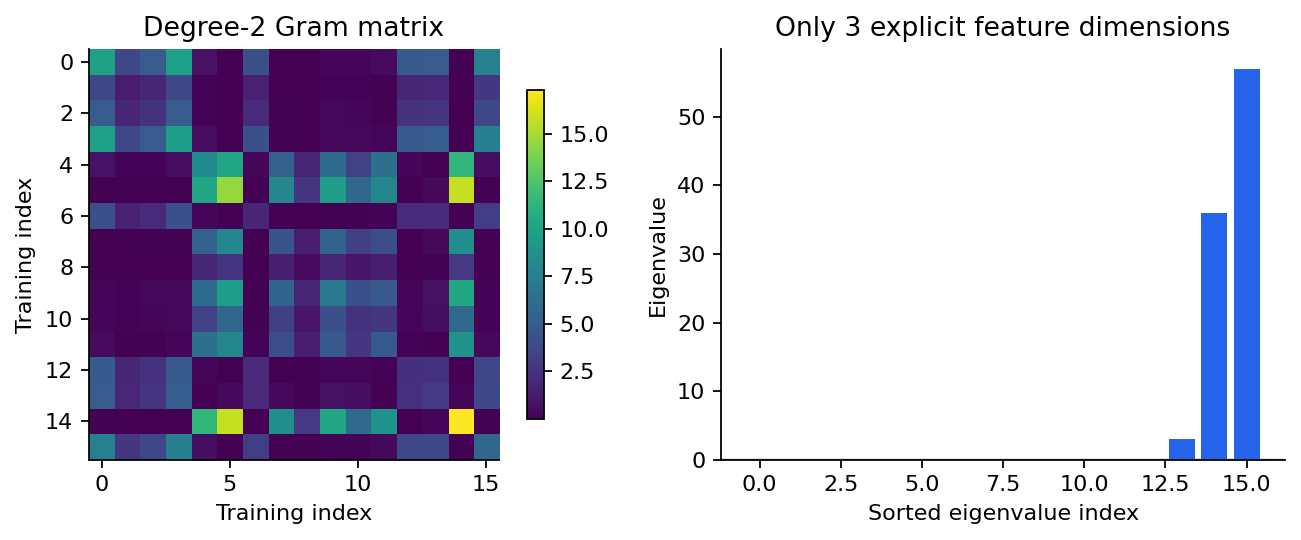

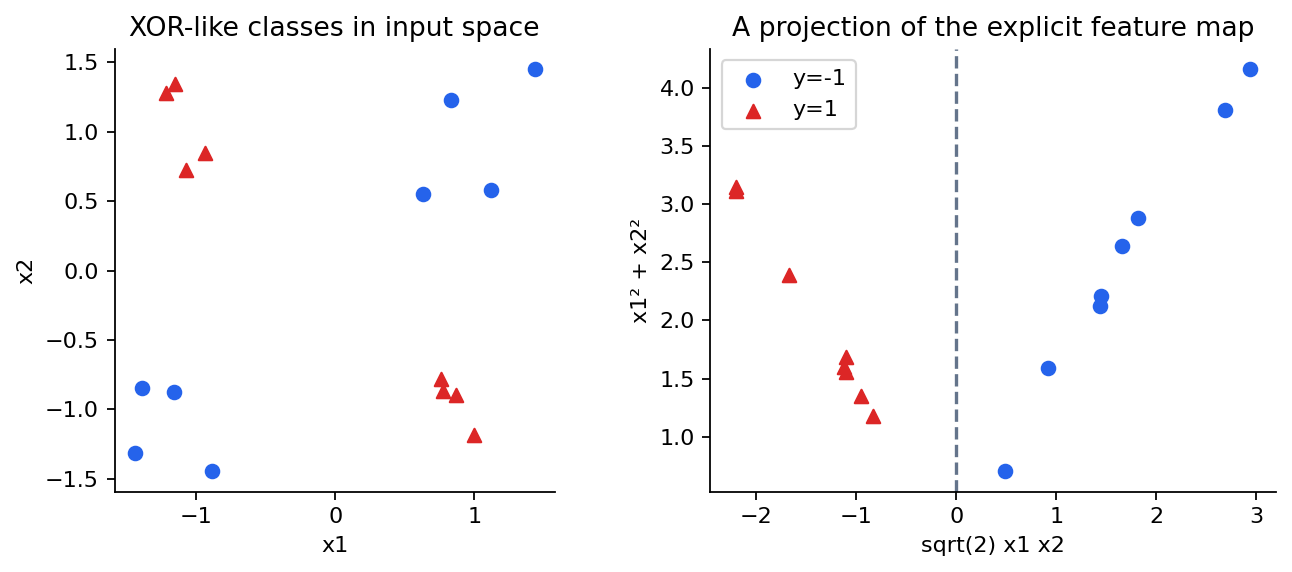

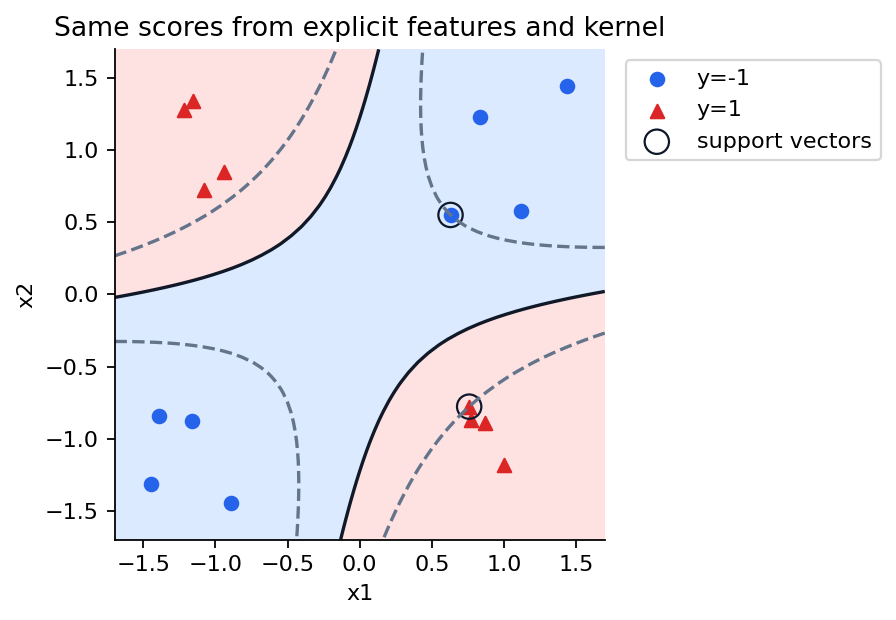

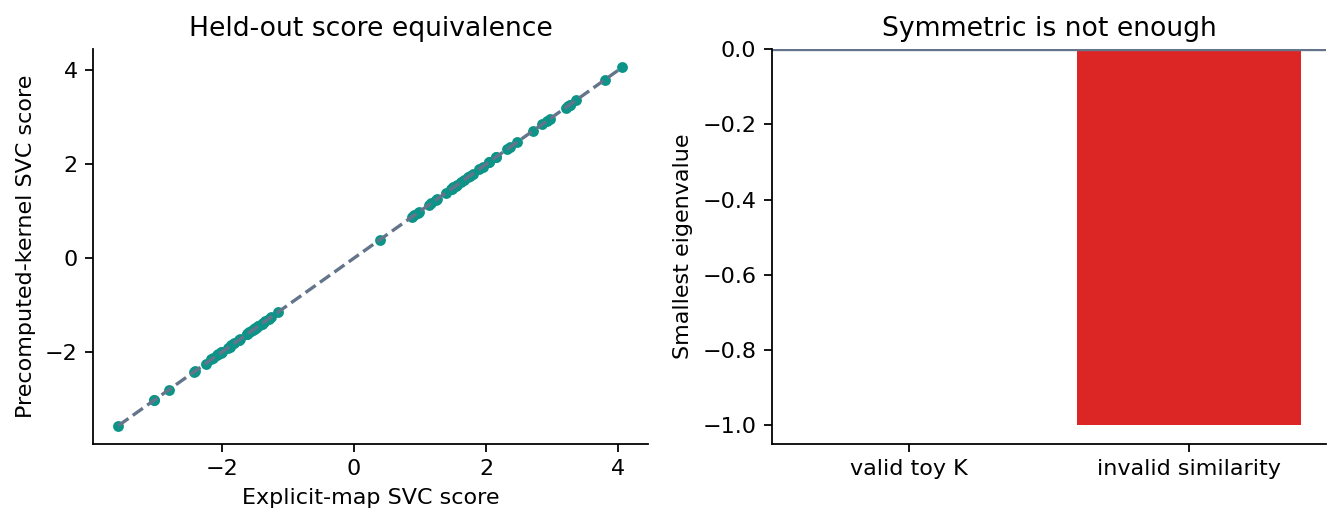

In [6]:
for name in build(result,'outputs/notebook/figures'):
    display(Image(filename=str(Path('outputs/notebook/figures')/name)))

## 完整测试再次重跑数值实验

In [7]:
from test_experiment import test
checks=test(result)
print({k:v for k,v in checks.items() if k!='check_names'})

{'status': 'passed', 'checks': 216, 'optimized': False, 'fresh_experiment_replayed': True}


## 自己解释
为什么alpha的上界是C？无内部支持向量时为什么不能直接平均b？一次Gram为PSD为什么不足以证明全域合法？详解见answers.pdf。